###
## Demonstrate Bayesian Strategy Analysis
###
This notebook demonstrates Bayesian strategy analysis for a single behavioural strategy.

>All parameters are defined in config.py.
You do NOT need to modify this notebook.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)



In [2]:
from config import (
    data_path, strategy_name, prior_type, decay_rate, save_output_csv,
)

# ============================
available_strategies = [
    s for s in dir(strategymodels)
    if callable(getattr(strategymodels, s)) and not s.startswith("_")
]
try:
    strategy_fcn = getattr(strategymodels, strategy_name)
except AttributeError:
    raise ValueError(
        f"Strategy '{strategy_name}' not found.\nAvailable strategies:\n{available_strategies}"
    )



In [ ]:

if "TrialIndex" not in TestData.columns:
    raise ValueError("Dataset must contain a 'TrialIndex' column.")

# Set priors, which are the parameters of the Beta distribution. The Beta distribution is a conjugate prior for the Bernoulli distribution, which models binary outcomes (success/failure). The parameters alpha and beta represent the number of successes and failures, respectively, in the prior belief about the strategy's performance.
alpha0, beta0 = set_priors(prior_type)

# Number of trials, which is the number of rows in the test data
no_Trials = len(TestData)

# Initialise counters, keep track of the number of successes and failures observed in the data. These counters will be updated as we iterate through the trials and will be used to update the parameters of the Beta distribution.
success_total = 0
failure_total = 0

# Output dataframe
Output = pd.DataFrame(
    columns=["Alpha", "Beta", "MAPprobability", "Precision"]
)

TestData.head()

,TrialIndex,Choice,CuePosition,Reward
0,1,left,left,yes
1,2,left,left,yes
2,3,left,left,yes
3,4,left,left,yes
4,5,left,left,yes


In [4]:
#Run Bayesian Strategy Analysis Across Trials

for trial in range(len(TestData)):
    #select data up to current trial
    rows_of_data = TestData.iloc[0:trial+1]   

    # test whether go-left was used   
    trial_type = strategy_fcn(rows_of_data)               
        
    [success_total, failure_total, Alpha, Beta] = update_strategy_posterior_probability(
     trial_type, 
     decay_rate,
     success_total, 
     failure_total,
     alpha0, beta0)
    
    #Summarise Beta distribution by calculating the MAP probability and precision (which is a measure of how peaked the distribution is, calculated as the inverse of the variance). The MAP probability gives us the most likely value of the strategy's success rate given the observed data and the prior belief, while the precision gives us an indication of how confident we are in that estimate.
    MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, 'MAP')
    precision = summaries_of_Beta_Distribution(Alpha, Beta, 'precision')
    
    #Store results for this trial
    new_row = {
        'Alpha':Alpha, 
        'Beta':Beta,
        'MAPprobability':MAPprobability, 
        'Precision':precision}    

    new_df= pd.DataFrame([new_row]) 
    Output = pd.concat([Output, new_df], ignore_index=True)    

# Save output    
if save_output_csv:
    Output.to_csv('Output.csv', index=False)

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_13517/3271439470.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output = pd.concat([Output, new_df], ignore_index=True)


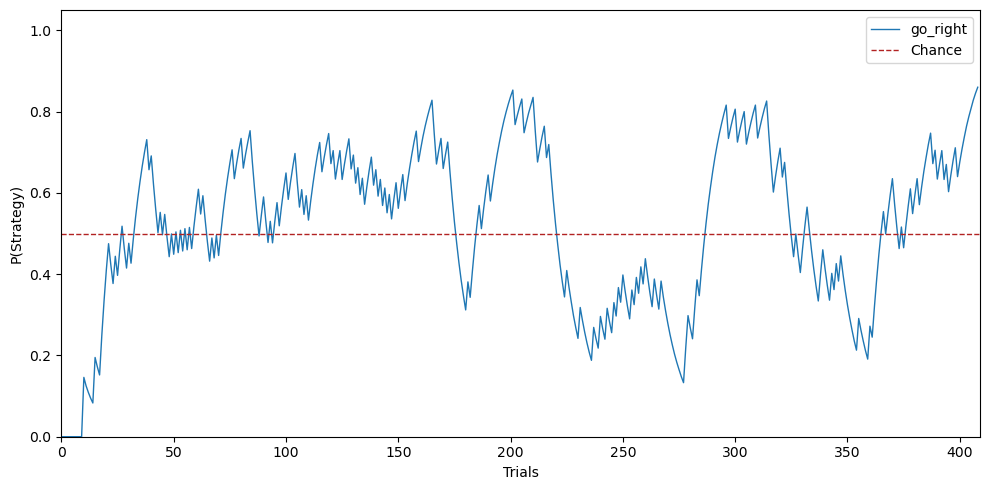

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(Output['MAPprobability'],
         linewidth=1.0,
         label=strategy_name)

plt.xlabel('Trials')
plt.ylabel('P(Strategy)')

plt.axhline(y=0.5,
            color='firebrick',
            linestyle='--',
            linewidth=1.0,
            label='Chance')

try:
    plotSessionStructure(TestData)
except Exception:
    pass

plt.axis([0, no_Trials, 0, 1.05])

plt.legend()
plt.tight_layout()
plt.show()

---

## Next Step

If you would like to analyse multiple strategies and reproduce
Figure 1 from the paper, proceed to:

**2_Replicate_Figure1.ipynb**

That notebook:
- Evaluates multiple strategies simultaneously
- Reproduces the main figure from the paper
- Introduces interpolation of null trials